In [1]:
import scarf

scarf.set_verbosity('WARNING')

scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

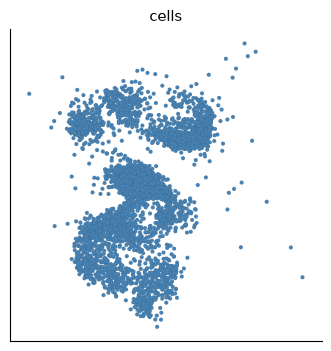

PlotResult(axes=1, tables=0, legends=0, scales=1, owns_figure=True, rendered=True)

In [2]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label='densMAP',
)
ds.plots.embedding(layout_key='RNA_densMAP')

Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 400: error is 2.78472 (50 iterations in 0.081046 seconds)


Iteration 450: error is 2.76277 (50 iterations in 0.089416 seconds)


Iteration 499: error is 2.7586 (50 iterations in 0.080811 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.135225 sec [21.7254%] |  Repulsive forces: 0.487204 sec [78.2746%]


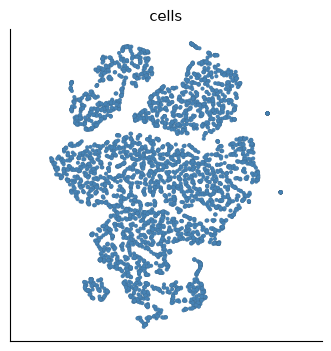

PlotResult(axes=1, tables=0, legends=0, scales=1, owns_figure=True, rendered=True)

In [3]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
)
ds.plots.embedding(layout_key='RNA_tSNE')

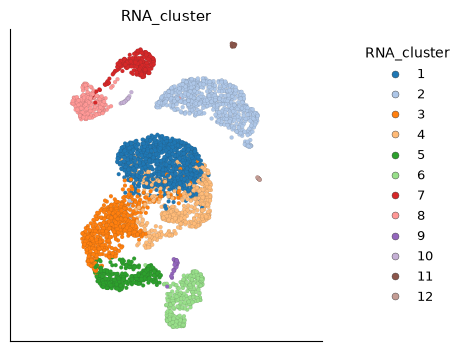

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [4]:
n_clusters = int(
    ds.cells.to_pandas_dataframe(
        columns=['RNA_leiden_cluster'], key='I'
    )['RNA_leiden_cluster'].nunique()
)
ds.run_clustering(n_clusters=n_clusters)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
)

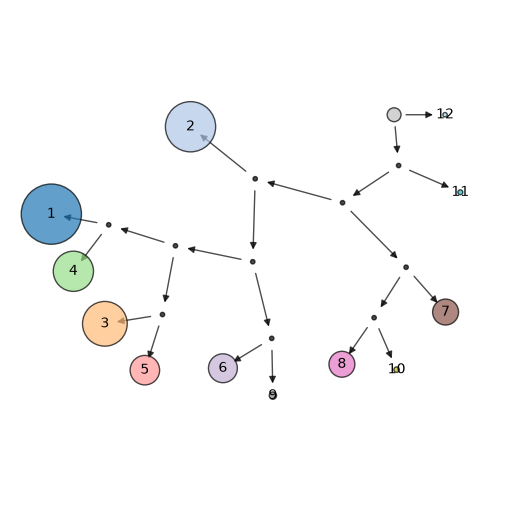

PlotResult(axes=1, tables=4, legends=1, scales=2, owns_figure=True, rendered=True)

In [5]:
ds.plots.cluster_tree(cluster_key='RNA_cluster', width=1)